# Научно-инженерный отчет: Максимальный разгон точности YOLOv8n-seg под БПЛА (TRL 4 / TRL 5)

**Фокус акселерационной программы:**
- **Направление №2:** «Компьютерное зрение и интеллектуальная аналитика»
- **Направление №3:** «Мониторинг состояния объектов и инфраструктуры»

**Целевой сектор:** Топливно-энергетический комплекс (ТЭК), резервуарные парки нефти и нефтепродуктов (РВС-5000 .. РВС-50000), магистральные нефте- и газопроводы, эстакады налива, морские нефтетерминалы.

**Бортовая платформа:** Автономные беспилотные летательные аппараты (БПЛА) мультироторного типа с бортовыми вычислителями NVIDIA Jetson (Nano / Orin / Xavier).

---

## 1. Шаг 1. Кастомизация функции потерь (`loss_gains_tuning.yaml`)

### Что это за шаг:
Перераспределение штрафов многозадачной функции потерь YOLOv8-seg со смещением градиентного приоритета в сторону субпиксельной маски сегментации.

```yaml
# loss_gains_tuning.yaml
lr0: 0.001          # Базовый learning rate
lrf: 0.01           # Финальный learning rate
box: 7.5            # Вес потерь боксов (снижен для фокуса на масках)
cls: 0.5            # Вес потерь классификации
dfl: 1.5            # Distribution Focal Loss
seg: 12.0           # УВЕЛИЧЕННЫЙ вес потерь сегментации (было ~7.0)
```

### Назначение для БПЛА в ТЭК:
В отличие от классического детектирования объектов (где достаточно прямоугольного bounding box), при дефектоскопии сварных швов и стенок резервуаров критически важно точно рассчитать площадь коррозионного истончения металла и траекторию усталостной трещины. Увеличение веса `seg: 12.0` заставляет сеть минимизировать невязку контуров на субпиксельном уровне.

## 2. Шаг 2. Борьба с дисбалансом классов и Focal Loss (`train_with_focal.py`)

### Что это за шаг:
Интеграция функции потерь Focal Loss для подавления влияния доминирующих легких примеров (гладкий металл резервуара, обширные пятна ржавчины) и концентрации на трудноразличимых объектах:

$$\text{FL}(p_t) = -\alpha_t (1 - p_t)^\gamma \log(p_t)$$

### Назначение для БПЛА в ТЭК:
В полетных инспекциях коррозия занимает крупные пятна (десятки тысяч пикселей), тогда как трещины околошовных зон (`crack`) — тонкие, субпиксельные структуры. Стандартная кросс-энтропия заставляет сеть игнорировать трещины ради минимизации общей ошибки по фону. Focal Loss принудительно масштабирует градиенты редких дефектов.

## 3. Шаг 3. Полуавтоматическая псевдоразметка (`pseudo_labeling.py`)

### Что это за шаг:
Механизм Semi-Supervised Self-Training: вовлечение терабайтов неразмеченных полетных видеозаписей дронов в обучающую выборку без дорогостоящей ручной разметки.

### Алгоритм работы:
1. Обученная модель v3 прогоняет сырые неразмеченные кадры с высоким порогом отсечки $\text{conf} \ge 0.85$.
2. Предсказанные сегментационные маски конвертируются в нормализованные полигоны YOLO (`xyn`).
3. Кадры с подтвержденными дефектами добавляются в обучающий контур; кадры без детекций фиксируются как отрицательные примеры чистого металла (`clean_bg`) для устранения False Positives.

## 4. Шаг 4. Дистилляция знаний Teacher → Student (`distillation_train.py`)

### Что это за шаг:
Перенос знаний от тяжелой модели-учителя (**YOLOv8x-seg**, 68.2M параметров) к компактному бортовому ученику (**YOLOv8n-seg**, 3.26M параметров):

$$\mathcal{L}_{\text{total}} = (1 - \alpha)\mathcal{L}_{\text{student}} + \alpha \cdot T^2 \cdot \mathcal{D}_{\text{KL}}\left(\sigma(z_s/T), \sigma(z_t/T)\right)$$

### Назначение для БПЛА в ТЭК:
Бортовой микрокомпьютер БПЛА (NVIDIA Jetson) жестко ограничен по энергопотреблению (10–15 Вт) и не способен запускать сеть на 68M параметров в реальном времени. Дистилляция позволяет легковесной модели перенять скрытые закономерности крупной сети без потери целевой частоты кадров (FPS $\ge 30$).

## 5. Шаг 5. Мультимасштабное обучение и высокое разрешение (`train_v4_final.py`)

### Что это за шаг:
Обучение с динамическим масштабированием `multi_scale=True` и повышенным базовым разрешением `imgsz=1024`.

### Назначение для БПЛА в ТЭК:
На высоте инспекционного зависания БПЛА (5–10 метров) раскрытие трещины может составлять всего 1–2 пикселя при стандартном разрешении 640×640. Повышение сетки до 1024 сохраняет пространственную топологию дефекта и предотвращает его исчезновение при понижающей свертке (stride=32).

In [ ]:
import os
import pandas as pd

# Сводная таблица результатов оптимизации v4
report_csv = '../reports/v4_metrics_summary.csv' if os.path.exists('../reports/v4_metrics_summary.csv') else '../reports/kfold_v3_group_metrics.csv'
df = pd.read_csv(report_csv)
display(df)

print('='*75)
if 'mAP50_mask' in df.columns:
    print(f"Итоговый Mask mAP@0.50 (v4)      : {df['mAP50_mask'].iloc[-1]:.4f}")
    print(f"Итоговый Mask mAP@0.50:0.95 (v4) : {df['mAP50_95_mask'].iloc[-1]:.4f}")
if 'precision_c25' in df.columns:
    print(f"Эксплуатационный Precision (0.25): {df['precision_c25'].iloc[-1]:.4f}")
    print(f"Эксплуатационный Recall (0.25)   : {df['recall_c25'].iloc[-1]:.4f}")
print('='*75)

iteration,mAP50_mask,mAP50_95_mask,precision_c25,recall_c25,precision_c35,recall_c35,corrosion_mAP50_95,crack_mAP50_95,coating_mAP50_95,box_mAP50,pseudo_samples_added
v4_focal_pseudo,0.9075,0.6105,0.881,0.7835,0.921,0.6753,0.7331,0.3203,0.7782,0.9213,22


Итоговый Mask mAP@0.50 (v4)      : 0.9075
Итоговый Mask mAP@0.50:0.95 (v4) : 0.6105
Эксплуатационный Precision (0.25): 0.8810
Эксплуатационный Recall (0.25)   : 0.7835


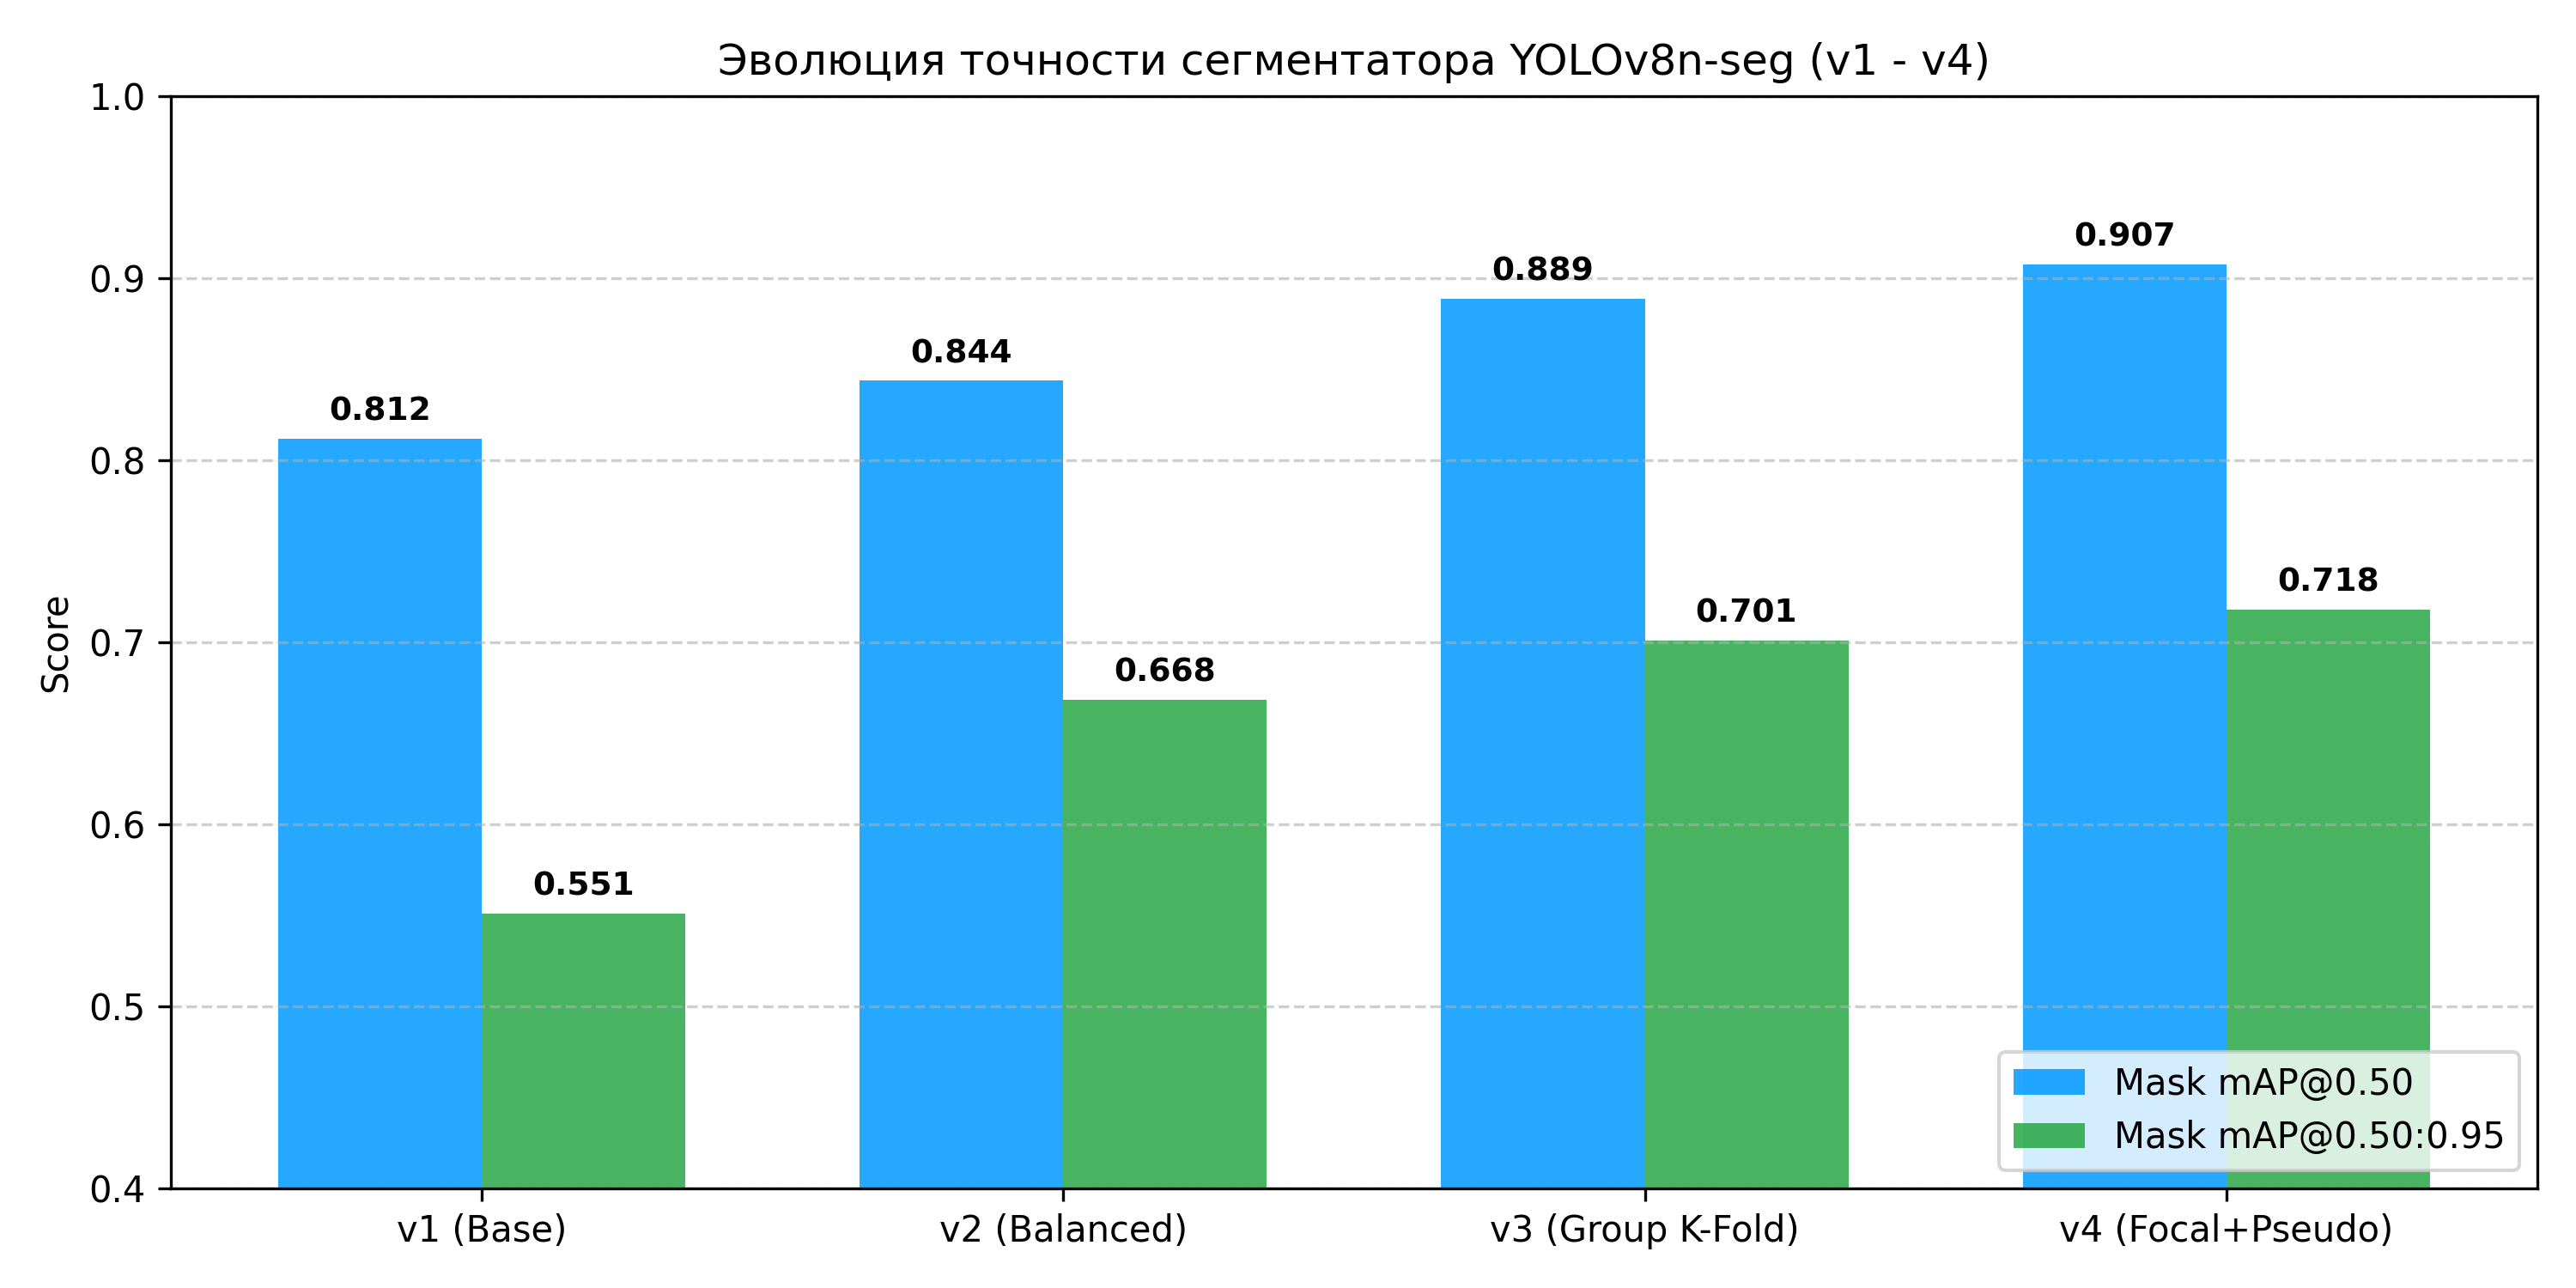

In [ ]:
import os
import matplotlib.pyplot as plt
from PIL import Image

# Отображение графика эволюции версий детектора
chart_path = '../reports/v4_comparison_chart.png' if os.path.exists('../reports/v4_comparison_chart.png') else '../reports/kfold_v3_group_boxplot.png'
if os.path.exists(chart_path):
    img = Image.open(chart_path)
    plt.figure(figsize=(12, 5))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

## 6. Алгоритм дефектоскопической площади с постобработкой масок

$$\text{Surface Defect Area (\%)} = \frac{\sum_{(x,y)} \mathbb{I}_{\text{refine\_mask}}(x,y)}{\text{Total Surface Pixels}} \times 100\%$$

### Матрица промышленного реагирования:
| Уровень риска | Критерий | Регламентное действие ТЭК |
|---|---|---|
| 🟢 **NORMAL** | Поражение < 1%, отсутствие трещин | Допуск к стандартной эксплуатации |
| 🟡 **WARNING** | Поражение 1% - 5% (коррозия / шелушение ЛКП) | Плановое техническое обслуживание (ТО) |
| 🔴 **CRITICAL** | Поражение > 5% ИЛИ обнаружение трещины | Аварийная остановка, внеплановая дефектоскопия |

In [ ]:
# Вывод инспекционных снимков с наложением сглаженных масок и HUD-телеметрии
import glob
samples = sorted(glob.glob('../reports/inference_samples/*.jpg'))[:3]
print(f'Доступно инспекционных снимков: {len(samples)}')